<a href="https://colab.research.google.com/github/aryajain0902/MedTrack-EHR-based-medicine-dispensation-system/blob/main/Analyst_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

In [6]:
uploaded = files.upload()

Saving people.csv to people.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [9]:
df = pd.read_csv("people.csv")   # make sure filename matches
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


step 1. EDA

In [10]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


,0
satisfactoryLevel,0
lastEvaluation,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent.company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


2. Preprocessing
a. check duplicates
b. remove duplicates
c. verify removed duplicates

> Add blockquote



In [14]:
print("Duplicate rows before removal:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after removal:", df.duplicated().sum())
print("Shape after preprocessing:", df.shape)

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Shape after preprocessing: (11991, 10)


3. Highest Experienced

In [17]:
print(df.columns)

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')


In [18]:
df.sort_values(by='timeSpent.company', ascending=False).head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
12447,0.69,0.88,3,164,10,0,0,0,management,medium
12636,0.79,0.65,3,235,10,0,0,0,technical,low
12078,0.64,0.52,5,258,10,1,0,0,management,high
13300,0.58,0.99,3,207,10,0,0,0,technical,low
11065,0.22,0.94,3,193,10,0,0,1,management,high


4. department wise analyst with highest experience


In [20]:
print("Highest experience department-wise:")
df.groupby('dept')['timeSpent.company'].max()

Highest experience department-wise:


,timeSpent.company
dept,
IT,10
RandD,8
accounting,10
hr,8
management,10
marketing,10
product_mng,10
sales,10
support,10


In [21]:
print("Average satisfaction level department-wise:")
df.groupby('dept')['satisfactoryLevel'].mean()

Average satisfaction level department-wise:


,satisfactoryLevel
dept,
IT,0.634016
RandD,0.627176
accounting,0.607939
hr,0.621947
management,0.631995
marketing,0.634770
product_mng,0.629825
sales,0.631349
support,0.634822


In [22]:
print("Average number of projects department-wise:")
df.groupby('dept')['numberOfProjects'].mean()

Average number of projects department-wise:


,numberOfProjects
dept,
IT,3.797131
RandD,3.850144
accounting,3.834138
hr,3.675541
management,3.837156
marketing,3.720654
product_mng,3.794461
sales,3.777092
support,3.820977


In [23]:
print("Average last evaluation department-wise:")
df.groupby('dept')['lastEvaluation'].mean()

Average last evaluation department-wise:


,lastEvaluation
dept,
IT,0.715051
RandD,0.712983
accounting,0.721900
hr,0.715691
management,0.726307
marketing,0.718440
product_mng,0.713790
sales,0.710398
support,0.722998


In [24]:
print("Attrition rate department-wise:")
df.groupby('dept')['left'].mean()

Attrition rate department-wise:


,left
dept,
IT,0.161885
RandD,0.122478
accounting,0.175523
hr,0.188020
management,0.119266
marketing,0.166419
product_mng,0.160350
sales,0.169805
support,0.171334


5. Highest salary department wise

In [25]:
df.groupby('dept')['salary'].value_counts()

dept         salary
IT           low        476
             medium     429
             high        71
RandD        medium     325
             low        322
             high        47
accounting   low        296
             medium     262
             high        63
hr           low        296
             medium     267
             high        38
management   medium     169
             low        139
             high       128
marketing    low        310
             medium     301
             high        62
product_mng  low        343
             medium     291
             high        52
sales        low       1553
             medium    1449
             high       237
support      low        867
             medium     828
             high       126
technical    low       1138
             medium     940
             high       166
Name: count, dtype: int64

6. Satisfactory level department wise

In [26]:
df.groupby('dept')['satisfactoryLevel'].agg(['max', 'min'])

,max,min
dept,,
IT,1.0,0.09
RandD,1.0,0.09
accounting,1.0,0.09
hr,1.0,0.09
management,1.0,0.09
marketing,1.0,0.09
product_mng,1.0,0.09
sales,1.0,0.09
support,1.0,0.09


7. Department wise low salary

In [28]:
print("Department wise  lowest salary")
df[df['salary'] == 'low'].groupby('dept').size()

Department wise  lowest salary


,0
dept,
IT,476
RandD,322
accounting,296
hr,296
management,139
marketing,310
product_mng,343
sales,1553
support,867


8. Department wise  projects


In [29]:
df.groupby('dept')['numberOfProjects'].mean()

,numberOfProjects
dept,
IT,3.797131
RandD,3.850144
accounting,3.834138
hr,3.675541
management,3.837156
marketing,3.720654
product_mng,3.794461
sales,3.777092
support,3.820977


9. Department wise  evaluation

In [30]:
df.groupby('dept')['lastEvaluation'].mean()

,lastEvaluation
dept,
IT,0.715051
RandD,0.712983
accounting,0.721900
hr,0.715691
management,0.726307
marketing,0.718440
product_mng,0.713790
sales,0.710398
support,0.722998


10. Department wise left

In [31]:
df.groupby('dept')['left'].mean()

,left
dept,
IT,0.161885
RandD,0.122478
accounting,0.175523
hr,0.188020
management,0.119266
marketing,0.166419
product_mng,0.160350
sales,0.169805
support,0.171334


11.	Relationship  (Data Manipulation, Visualization)
-	No. of projects vs Salary
-	No. of project vs left
-	Satisfactory level vs No. of Projects
-	Promotion vs salary
-	Dept.  vs salary
-	Avge Monthly Hours vs satisfactory level
-	Satisfactory level vs left
-	Satisfactory level vs salary
-	Promotion vs left
-	No. of Project vs Promotion in 5 Years
-	Promotion vs left
-	Left vs salary
-	Work accident vs left
-	Avge Monthly Hours vs salary



No. of Projects vs Salary


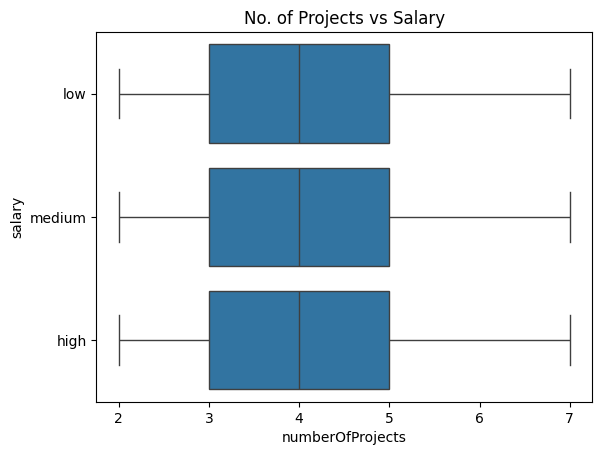

No. of Projects vs Left


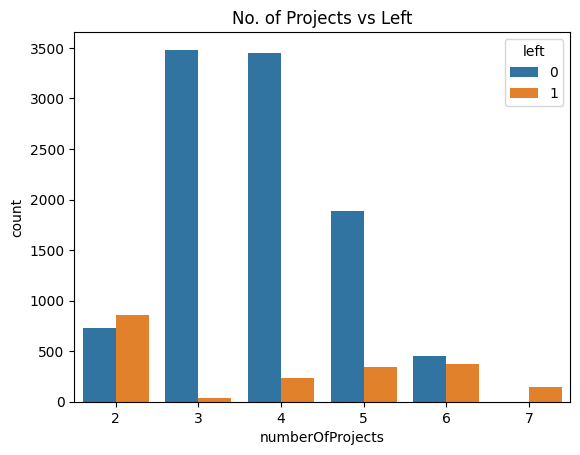

Satisfactory Level vs No. of Projects


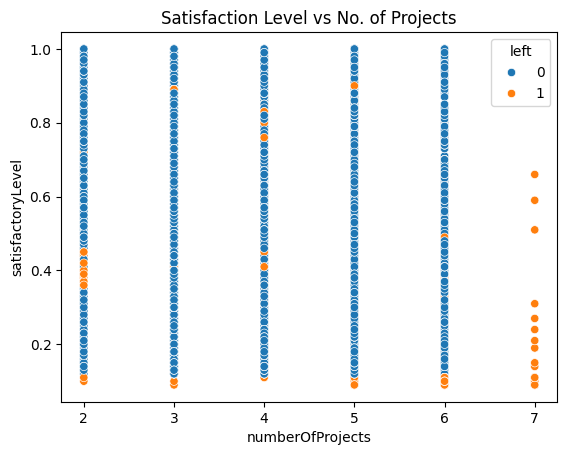

Promotion vs Salary


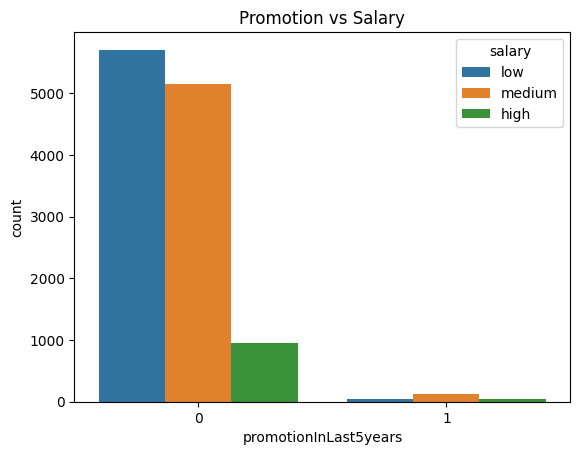

Department vs Salary


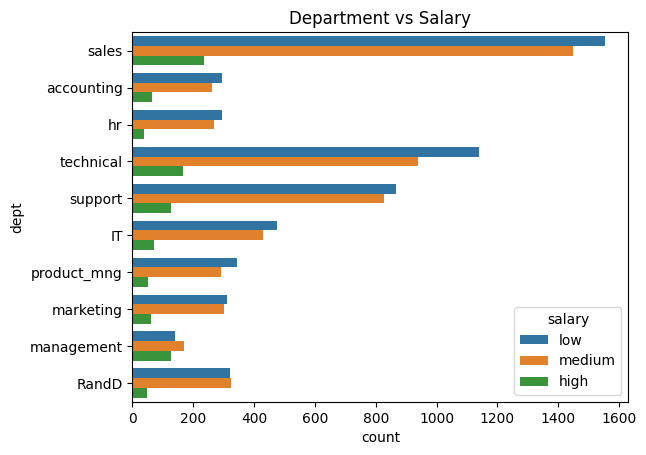

Avg Monthly Hours vs Satisfaction Level


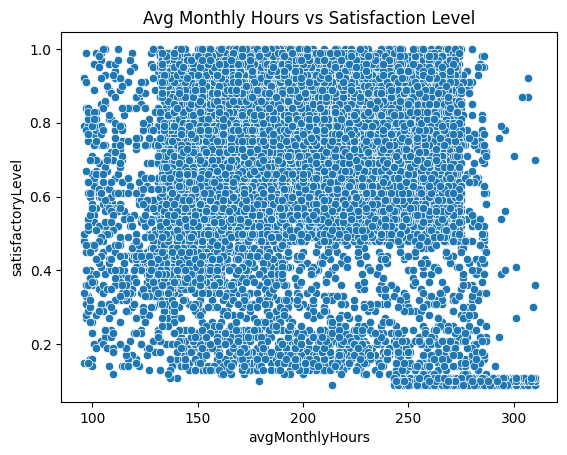

Satisfaction Level vs Left


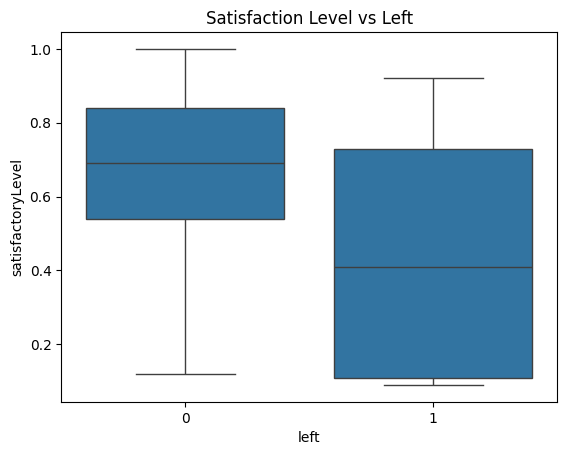

Satisfaction Level vs Salary


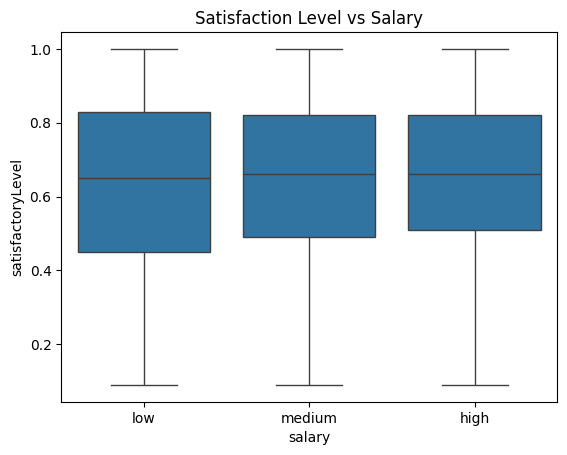

Promotion vs Left


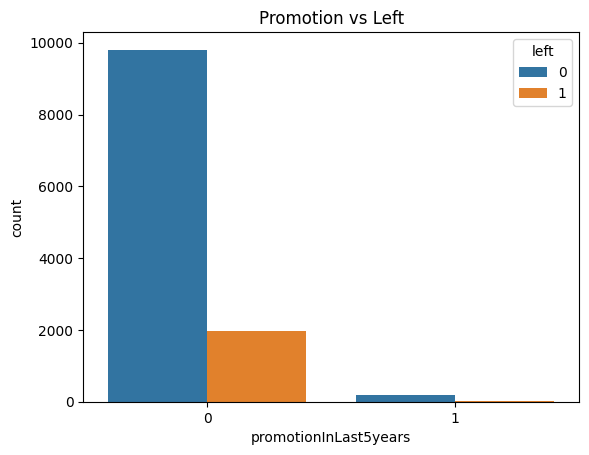

No. of Projects vs Promotion in 5 Years


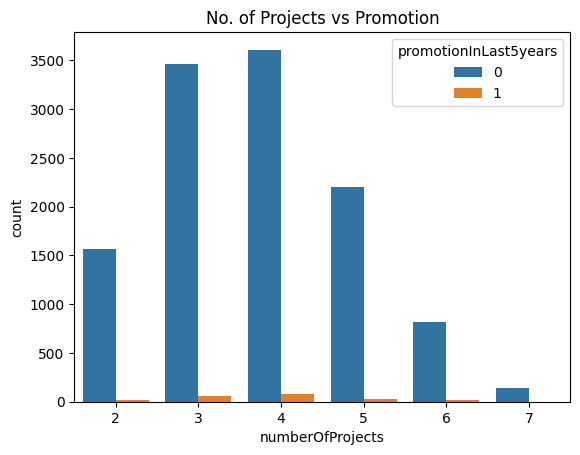

Promotion vs Left


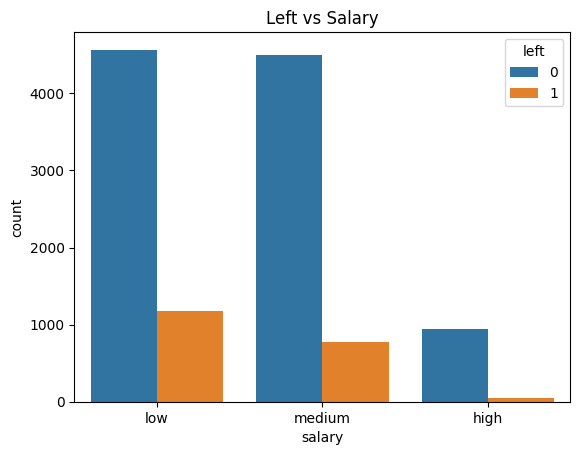

Work Accident vs Left


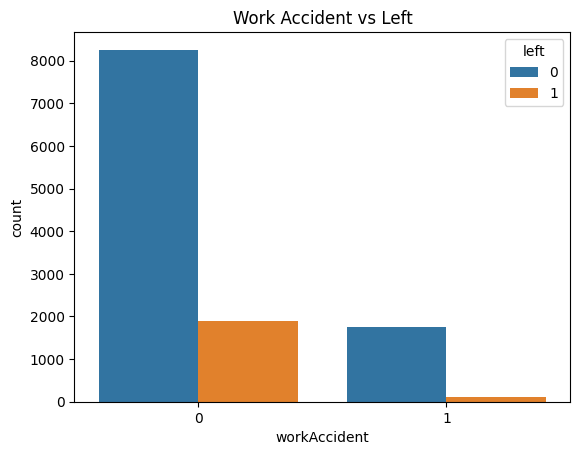

Avg Monthly Hours vs Salary


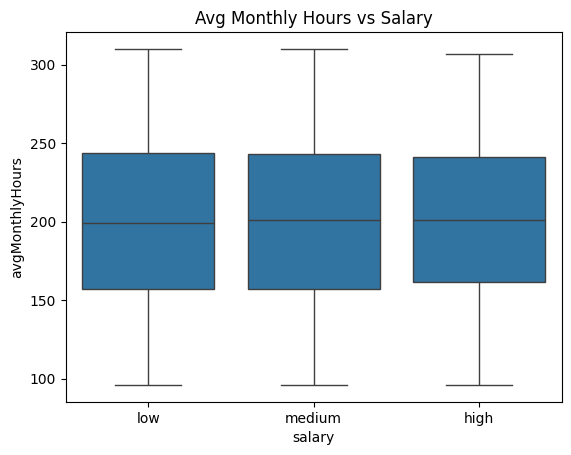

In [33]:
print("No. of Projects vs Salary")
sns.boxplot(x='numberOfProjects', y='salary', data=df)
plt.title("No. of Projects vs Salary")
plt.show()
print("No. of Projects vs Left")
sns.countplot(x='numberOfProjects', hue='left', data=df)
plt.title("No. of Projects vs Left")
plt.show()
print("Satisfactory Level vs No. of Projects")
sns.scatterplot(x='numberOfProjects', y='satisfactoryLevel', hue='left', data=df)
plt.title("Satisfaction Level vs No. of Projects")
plt.show()
print("Promotion vs Salary")
sns.countplot(x='promotionInLast5years', hue='salary', data=df)
plt.title("Promotion vs Salary")
plt.show()
print("Department vs Salary")
sns.countplot(y='dept', hue='salary', data=df)
plt.title("Department vs Salary")
plt.show()
print("Avg Monthly Hours vs Satisfaction Level")
sns.scatterplot(x='avgMonthlyHours', y='satisfactoryLevel', data=df)
plt.title("Avg Monthly Hours vs Satisfaction Level")
plt.show()
print("Satisfaction Level vs Left")
sns.boxplot(x='left', y='satisfactoryLevel', data=df)
plt.title("Satisfaction Level vs Left")
plt.show()
print("Satisfaction Level vs Salary")
sns.boxplot(x='salary', y='satisfactoryLevel', data=df)
plt.title("Satisfaction Level vs Salary")
plt.show()
print("Promotion vs Left")
sns.countplot(x='promotionInLast5years', hue='left', data=df)
plt.title("Promotion vs Left")
plt.show()
print("No. of Projects vs Promotion in 5 Years")
sns.countplot(x='numberOfProjects', hue='promotionInLast5years', data=df)
plt.title("No. of Projects vs Promotion")
plt.show()
print("Promotion vs Left")
sns.countplot(x='salary', hue='left', data=df)
plt.title("Left vs Salary")
plt.show()
print("Work Accident vs Left")
sns.countplot(x='workAccident', hue='left', data=df)
plt.title("Work Accident vs Left")
plt.show()
print("Avg Monthly Hours vs Salary")
sns.boxplot(x='salary', y='avgMonthlyHours', data=df)
plt.title("Avg Monthly Hours vs Salary")
plt.show()

12. Encoding and standardising

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['salary'] = le.fit_transform(df['salary'])
df['dept'] = le.fit_transform(df['dept'])

df[['salary', 'dept']].head()

,salary,dept
0,1,7
1,2,7
2,2,7
3,1,7
4,1,7


13. Choose appropriate variables in x and y

In [35]:
X = df.drop('left', axis=1)
y = df['left']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11991, 9)
y shape: (11991,)


14. 14.	Use 75% for training and 25% testing

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8993, 9)
Testing set: (2998, 9)


14. a. Standardization

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Standardization done")

Standardization done


15. Using logistic regression

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [39]:
#predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

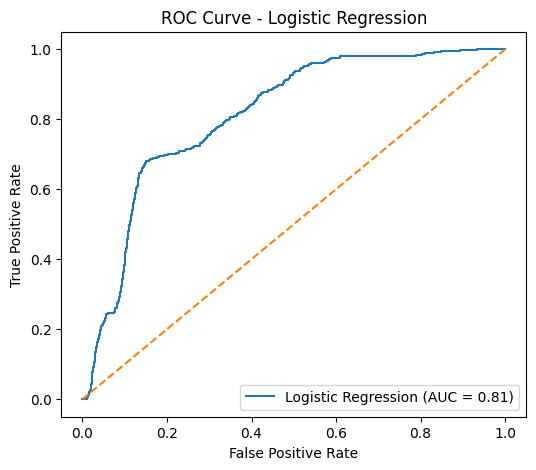

In [40]:
# plot ROC curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

16. confusion matrix

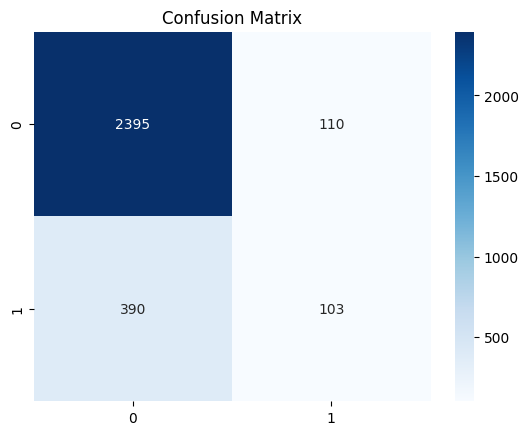

In [41]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

17. Classification Report

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2505
           1       0.48      0.21      0.29       493

    accuracy                           0.83      2998
   macro avg       0.67      0.58      0.60      2998
weighted avg       0.80      0.83      0.80      2998



18. Accuracy Score

In [43]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8332221480987325
